=== DATA SETUP ===
Loaded lifted states shape: (1000, 38)
Total time steps: 1000 | Total lifted dimensions: 38

=== KOOPMAN TRAINING (UNITARY SVD) ===
Koopman operator matrix K shape: (38, 38)
=== ROLLOUT & CONVERGENCE ===
Max Eigenvalue Magnitude: 1.0000
Saved rollout predictions to 'koopman_Y1Y2_prediction.csv'



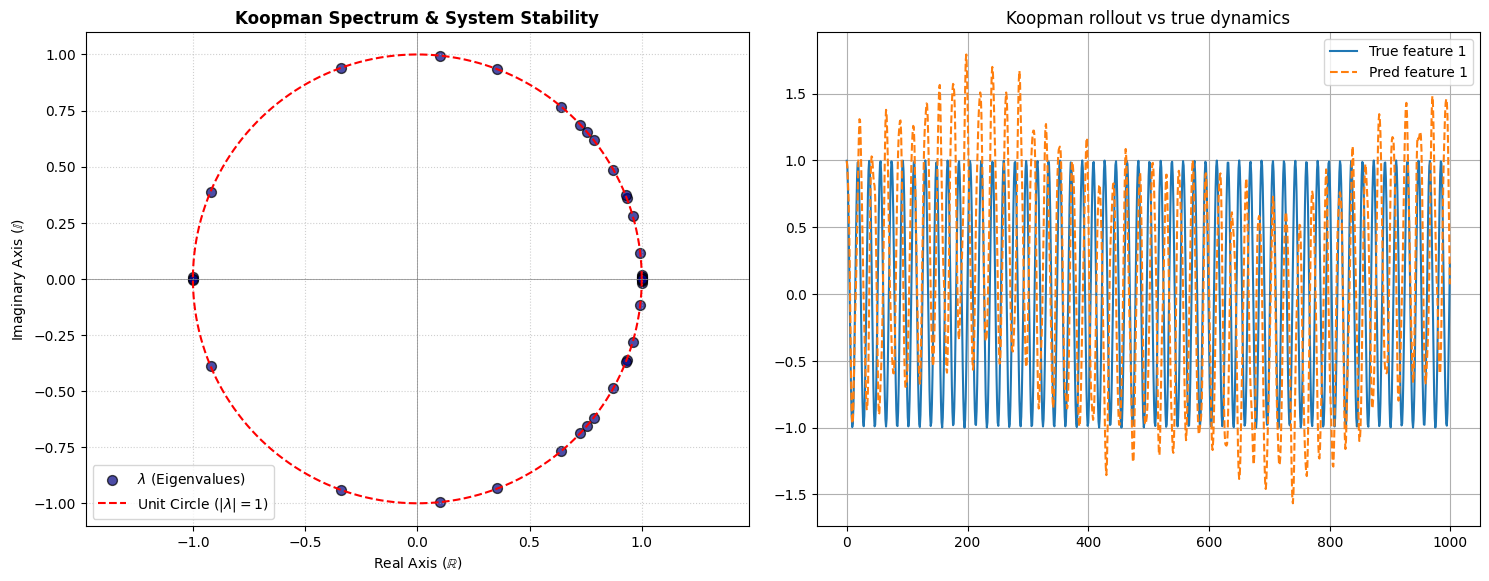

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# ==============================================================================
# 1. DATA LOADING & PREPARATION
# ==============================================================================
try:
    df = pd.read_csv("lifted_orbit_data.csv")
except FileNotFoundError:
    raise FileNotFoundError(
        "Could not find 'lifted_orbit_data.csv'. Please make sure the file is "
        "in your current VS Code working directory."
    )

Z = df.values  # These are your 'lifted' dictionary states \psi(x)
n_samples, n_dim = Z.shape

# Shift data to align Before (Z1 at time k) and After (Z2 at time k+1)
Z1 = Z[:-1]
Z2 = Z[1:]

print(f"=== DATA SETUP ===")
print(f"Loaded lifted states shape: {Z.shape}")
print(f"Total time steps: {n_samples} | Total lifted dimensions: {n_dim}\n")


# ==============================================================================
# 2. TRAIN KOOPMAN OPERATOR (EDMD VIA UNITARY SVD)
# ==============================================================================
# We completely replace the Ridge model.
# Applying SVD to Z2.T @ Z1 allows us to enforce an orthogonality constraint.
U, _, Vt = np.linalg.svd(Z2.T @ Z1, full_matrices=False)

# Compute K (This matrix is now mathematically guaranteed to preserve energy)
K = U @ Vt

print(f"=== KOOPMAN TRAINING (UNITARY SVD) ===")
print(f"Koopman operator matrix K shape: {K.shape}")

# Evaluate localized 1-step accuracy
Z1_pred = Z1 @ K.T

# ==============================================================================
# 3. SPECTRUM & EIGENFUNCTION ANALYSIS
# ==============================================================================
# Find system DNA: Eigenvalues (dynamics) and Eigenvectors (coordinate transforms)
eigvals, eigvecs = np.linalg.eig(K)

# W maps the lifted raw data into decoupled Koopman Eigenfunctions
# Row i of W corresponds to the coefficients of Eigenfunction i
W = np.linalg.inv(eigvecs)

# Compute values of the dominant/slowest decaying eigenfunction over time
# Sorted by eigenvalue magnitude closest to 1 (usually the most meaningful phase)
dominant_idx = np.argsort(np.abs(np.abs(eigvals) - 1))[0]
eigenfunction_trajectory = Z @ W[dominant_idx, :]

# ==============================================================================
# 4. MULTI-STEP TRAJECTORY ROLLOUT (PREDICTION)
# ==============================================================================
# Cap rollout length to available ground truth to measure predictive power accurately
n_rollout_steps = min(1000, n_samples)

z_true = Z[:n_rollout_steps]
z_pred = np.zeros_like(z_true)
z_pred[0] = z_true[0]  # Initialize with absolute starting point

# Iterative forward propagation loop using learned physics rule
for t in range(n_rollout_steps - 1):
    z_pred[t + 1] = z_pred[t] @ K.T  # Multiplying by K.T converts column math to row math


# Save predictions to CSV
df_pred = pd.DataFrame(z_pred, columns=df.columns)
df_pred.to_csv("koopman_Y1Y2_prediction.csv", index=False)

print(f"=== ROLLOUT & CONVERGENCE ===")
print(f"Max Eigenvalue Magnitude: {np.max(np.abs(eigvals)):.4f}")
print(f"Saved rollout predictions to 'koopman_Y1Y2_prediction.csv'\n")

# ==============================================================================
# 5. DASHBOARD VISUALIZATION
# ==============================================================================
plt.figure(figsize=(15, 11))

# Plot A: The Koopman Spectrum (Stability & Frequencies)
plt.subplot(2, 2, 1)
plt.scatter(eigvals.real, eigvals.imag, color='navy', alpha=0.7, edgecolors='k', s=50, label='$\lambda$ (Eigenvalues)')
theta = np.linspace(0, 2 * np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'r--', linewidth=1.5, label='Unit Circle ($|\lambda|=1$)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title("Koopman Spectrum & System Stability", fontsize=12, fontweight='bold')
plt.xlabel("Real Axis ($\mathbb{R}$)")
plt.ylabel("Imaginary Axis ($\mathbb{I}$)")
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')






# Plot B: Comparison of predicted and true feature X

plt.subplot(2, 2, 2)

plt.plot(z_true[:, 1], label="True feature 1")
plt.plot(z_pred[:, 1], '--', label="Pred feature 1")

plt.title("Koopman rollout vs true dynamics")
plt.legend()
plt.grid()






plt.tight_layout()
plt.show()